# Add J/Z from SignAlphaSet videos

This notebook trains a **separate** J/Z/NEITHER sequence model. It never overwrites your existing `keypoint.csv`, label CSV, static model or `app.py`.

Use the Python kernel where TensorFlow, OpenCV and MediaPipe are installed (the same environment as your project when possible). Run cells from top to bottom. Training is done here, not through camera keyboard shortcuts.

Dataset: [SignAlphaSet v3](https://doi.org/10.17632/8fmvr9m98w.3), Bindu Garg, Manisha Kasar, Achyut Kashyap, Amber Vats, Gunjan Sharma and Aditya Hange, CC BY 4.0. The local download contains 10 J videos, 10 Z videos and 240 other alphabet videos. Other letters provide NEITHER examples.

**Small experimental dataset:** accuracy on a few held-out clips does not establish webcam accuracy. Do not report it as signer-independent accuracy; filenames do not identify signers.


In [19]:
from pathlib import Path
import sys
import json
from collections import Counter

PROJECT = Path(r"C:\Users\USER\OneDrive\เดสก์ท็อป\Hand_Proj\SignBridge_V2\hand-gesture-recognition-mediapipe")
DATASET = PROJECT.parent / "ASL_dynamic"
OUTPUT = PROJECT / "model" / "jz_external"
TASK_PATH = PROJECT.parent.parent / "SignBridge" / "hand_landmarker.task"
sys.path.insert(0, str(PROJECT))
import numpy as np
import cv2
import mediapipe as mp
import tensorflow as tf
from jz_external import inventory, preview, prepare, train, LABELS

assert DATASET.is_dir(), f"Dataset folder not found: {DATASET}"
if not hasattr(mp, "solutions"):
    assert TASK_PATH.is_file(), f"Missing MediaPipe task file: {TASK_PATH}"
print("Python:", sys.executable)
print("Dataset:", DATASET)
print("New outputs only:", OUTPUT)


Python: c:\Users\USER\AppData\Local\Programs\Python\Python311\python.exe
Dataset: C:\Users\USER\OneDrive\เดสก์ท็อป\Hand_Proj\SignBridge_V2\ASL_dynamic
New outputs only: C:\Users\USER\OneDrive\เดสก์ท็อป\Hand_Proj\SignBridge_V2\hand-gesture-recognition-mediapipe\model\jz_external


## 1. Check the videos
Only the `.avi`/video files are used. Individual JPG frames must not be mixed into training independently, because that loses movement order and can leak the same clip into training and testing.


In [20]:
rows = inventory(DATASET)
print("Videos by training class:", dict(Counter(r["label"] for r in rows)))
for r in rows:
    if r["label"] in ("J", "Z"):
        print(r["path"], round(r["duration"], 2), "seconds")


Videos by training class: {'NEITHER': 240, 'J': 10, 'Z': 10}
J/J_clip1.avi 2.8 seconds
J/J_clip10.avi 3.8 seconds
J/J_clip2.avi 3.47 seconds
J/J_clip3.avi 1.07 seconds
J/J_clip4.avi 1.1 seconds
J/J_clip5.avi 1.03 seconds
J/J_clip6.avi 3.5 seconds
J/J_clip7.avi 3.47 seconds
J/J_clip8.avi 3.7 seconds
J/J_clip9.avi 3.8 seconds
Z/Z_clip1.avi 3.5 seconds
Z/Z_clip10.avi 3.87 seconds
Z/Z_clip2.avi 3.73 seconds
Z/Z_clip3.avi 3.63 seconds
Z/Z_clip4.avi 3.53 seconds
Z/Z_clip5.avi 3.7 seconds
Z/Z_clip6.avi 3.7 seconds
Z/Z_clip7.avi 3.93 seconds
Z/Z_clip8.avi 4.0 seconds
Z/Z_clip9.avi 3.97 seconds


## 2. Review the signs and trim setup movements
Change `VIDEO` and run the next cell to watch each J/Z clip. The playback includes a time label. Verify that the folder label matches the sign and the complete motion is visible. Some supplied clips include unrelated starting poses or preparation; do not train blindly on these.

Use `TRIMS` in the next cell for start/end seconds, and `EXCLUDE` for mislabeled or unsuitable videos. Preserve the complete sign. These settings do not modify the source videos.


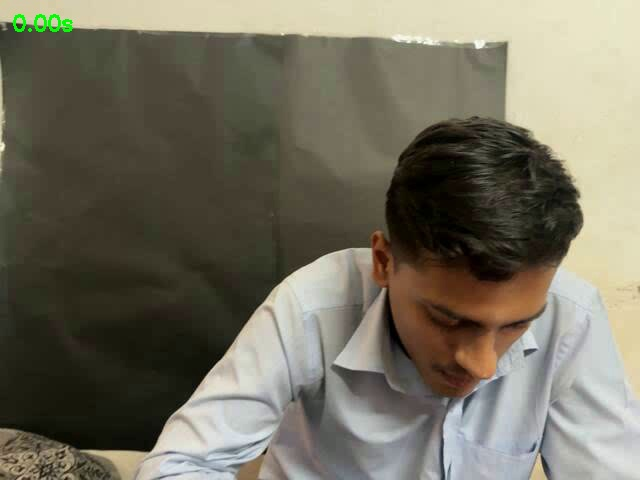

In [21]:
VIDEO = "J/J_clip1.avi"  # Change to e.g. "Z/Z_clip1.avi"
preview(DATASET / VIDEO)


In [22]:
# Example format ONLY: {"J/J_clip1.avi": (0.8, 2.5)}
# Choose actual times after watching the clips; the example is not a verified trim.
TRIMS = {}
EXCLUDE = []

# Set True only after reviewing the J/Z videos above.
VIDEOS_REVIEWED = True


## 3. Extract hand movement sequences
Run after video review. MediaPipe extracts 21 hand points per frame. Each complete video is resampled to 32 time steps; movement order is retained. Left-hand coordinates are mirrored into a common orientation. Low-quality clips are rejected and listed in a report.

This can take several minutes on CPU. It saves only new files under `model/jz_external/prepared`. If you change trims or exclusions, rerun this cell and retrain.


In [23]:
assert VIDEOS_REVIEWED, "Review J/Z videos, then set VIDEOS_REVIEWED=True."
chosen = [r for r in rows if r["path"] not in EXCLUDE]
accepted, rejected = prepare(DATASET, chosen, TRIMS, TASK_PATH, OUTPUT / "prepared")
print("Accepted:", dict(Counter(r["label"] for r in accepted)))
print("Rejected:", len(rejected))
for r in rejected:
    print(r["path"], ":", r["reason"])


1/260 processed; 1 accepted; 0 rejected
2/260 processed; 2 accepted; 0 rejected
3/260 processed; 3 accepted; 0 rejected
4/260 processed; 4 accepted; 0 rejected
5/260 processed; 5 accepted; 0 rejected
6/260 processed; 6 accepted; 0 rejected
7/260 processed; 7 accepted; 0 rejected
8/260 processed; 8 accepted; 0 rejected
9/260 processed; 9 accepted; 0 rejected
10/260 processed; 10 accepted; 0 rejected
11/260 processed; 11 accepted; 0 rejected
12/260 processed; 12 accepted; 0 rejected
13/260 processed; 13 accepted; 0 rejected
14/260 processed; 14 accepted; 0 rejected
15/260 processed; 15 accepted; 0 rejected
16/260 processed; 16 accepted; 0 rejected
17/260 processed; 17 accepted; 0 rejected
18/260 processed; 18 accepted; 0 rejected
19/260 processed; 19 accepted; 0 rejected
20/260 processed; 20 accepted; 0 rejected
21/260 processed; 21 accepted; 0 rejected
22/260 processed; 22 accepted; 0 rejected
23/260 processed; 23 accepted; 0 rejected
24/260 processed; 24 accepted; 0 rejected
25/260 pro

## 4. Train the new J/Z model
Entire videos are separated into approximately 60% training, 20% validation and 20% testing within each source letter. No frames from the same video cross splits. This is **not a split by person or recording session**. Related clips of the same signer may occur in multiple splits.

The model is a small GRU sequence classifier with outputs NEITHER/J/Z. Class weighting prevents the many negative clips from overwhelming the few J/Z clips. The test split is used only after training and early stopping.


In [24]:
model, history, report, MODEL_FOLDER = train(
    OUTPUT / "prepared" / "sequences.npz", OUTPUT, epochs=120
)
print("Saved model:", MODEL_FOLDER / "motion.keras")
print("Saved evaluation:", MODEL_FOLDER / "report.json")


Epoch 1/120
10/10 - 3s - 274ms/step - accuracy: 0.4178 - loss: 1.2126 - val_accuracy: 0.4118 - val_loss: 1.0564
Epoch 2/120
10/10 - 0s - 21ms/step - accuracy: 0.5411 - loss: 1.1110 - val_accuracy: 0.4510 - val_loss: 1.0155
Epoch 3/120
10/10 - 0s - 16ms/step - accuracy: 0.6027 - loss: 1.0264 - val_accuracy: 0.6078 - val_loss: 0.9666
Epoch 4/120
10/10 - 0s - 11ms/step - accuracy: 0.6986 - loss: 0.9309 - val_accuracy: 0.7451 - val_loss: 0.8924
Epoch 5/120
10/10 - 0s - 14ms/step - accuracy: 0.7945 - loss: 0.9276 - val_accuracy: 0.8039 - val_loss: 0.8057
Epoch 6/120
10/10 - 0s - 16ms/step - accuracy: 0.7877 - loss: 0.9140 - val_accuracy: 0.8039 - val_loss: 0.7685
Epoch 7/120
10/10 - 0s - 15ms/step - accuracy: 0.8493 - loss: 0.8905 - val_accuracy: 0.8235 - val_loss: 0.7599
Epoch 8/120
10/10 - 0s - 11ms/step - accuracy: 0.7877 - loss: 0.8511 - val_accuracy: 0.8235 - val_loss: 0.7356
Epoch 9/120
10/10 - 0s - 14ms/step - accuracy: 0.8904 - loss: 0.8783 - val_accuracy: 0.8039 - val_loss: 0.7106


## 5. Inspect performance
Check **J and Z recall**, not only overall accuracy. A model that always predicts NEITHER can have high overall accuracy because the data is imbalanced. Results here measure pre-recorded clips, not webcam recognition.


Overall accuracy: 96.1%
Balanced accuracy: 98.6%
Recall: {'NEITHER': 0.9574468085106383, 'J': 1.0, 'Z': 1.0}


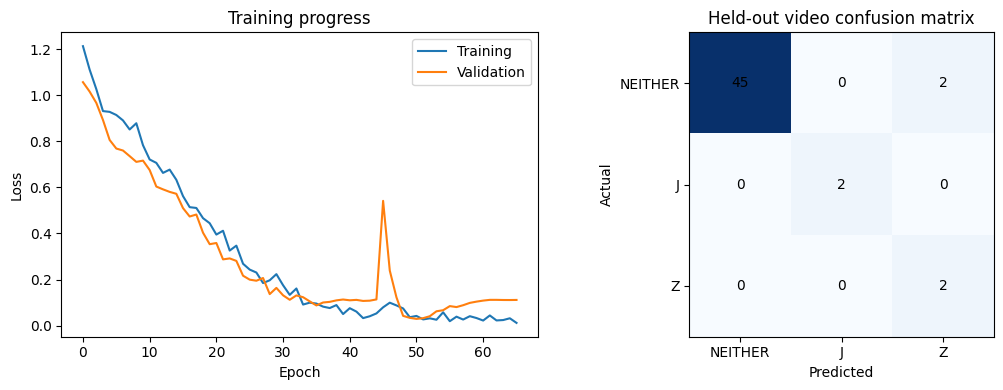

In [25]:
import matplotlib.pyplot as plt
print(f"Overall accuracy: {report['accuracy']:.1%}")
print(f"Balanced accuracy: {report['balanced_accuracy']:.1%}")
print("Recall:", report["recall_by_class"])
matrix = np.array(report["confusion_matrix"])
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history.history["loss"], label="Training")
axes[0].plot(history.history["val_loss"], label="Validation")
axes[0].set(xlabel="Epoch", ylabel="Loss", title="Training progress")
axes[0].legend()
axes[1].imshow(matrix, cmap="Blues")
axes[1].set(xticks=range(3), yticks=range(3), xticklabels=LABELS, yticklabels=LABELS,
            xlabel="Predicted", ylabel="Actual", title="Held-out video confusion matrix")
for i in range(3):
    for j in range(3):
        axes[1].text(j, i, str(matrix[i, j]), ha="center", va="center", color="black")
plt.tight_layout()
plt.show()


## 6. Next: webcam integration
Your original `python app.py` still uses the original static classifier. This notebook does not silently activate the new model.

After training, share `report.json` and the saved model folder. Check the J/Z results and test new webcam sequences before connecting the motion model to the static app. Inference must use the same 32-step preprocessing and motion boundaries; feeding one static frame into this model is incorrect.

With only ten original videos per motion letter, this is an initial experiment. More independent signers and realistic negative movements may be needed. Keep a fresh test set for final reporting if you repeatedly tune using these results.
